# FFT Analysis & FFTAwareNet Training

This notebook:
1. Visualizes average frequency spectra of real vs fake images (a strong figure for your report)
2. Builds a 4-channel (RGB + FFT) dataset wrapper
3. Trains `FFTAwareNet` and compares it against the baseline/transfer models

Run this AFTER you've trained `baseline` and `transfer` via `src/train.py`,
and after you've placed the real dataset into `data/train`, `data/valid`, `data/test`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import glob
import numpy as np
import matplotlib.pyplot as plt
import torch

from src import config
from src.fft_utils import average_spectrum, compute_fft_magnitude, build_rgb_fft_tensor

## 1. Average spectrum: real vs fake

This is the single most persuasive figure for the "why frequency domain matters" part of your report/viva.

Using 300 real and 300 fake images


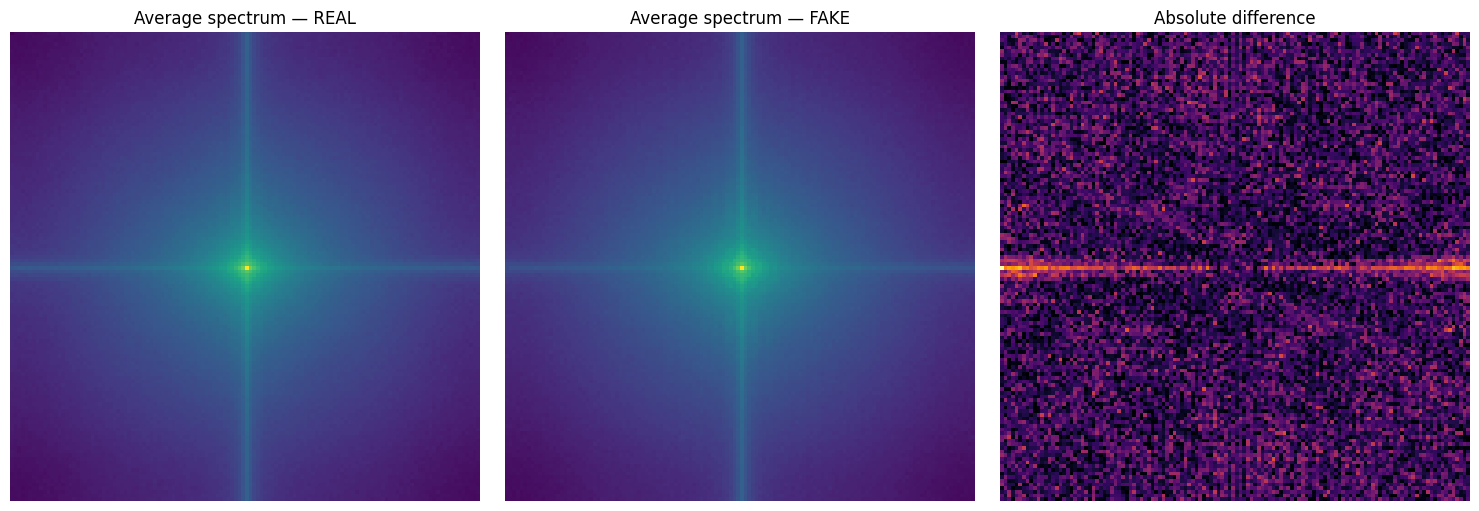

Saved figure to outputs/fft/average_spectrum_comparison.png
Look for bright spokes/rings/grid patterns in FAKE that are absent in REAL —
these come from GAN upsampling (transposed convolution) artifacts.


In [2]:
real_paths = glob.glob(os.path.join(config.TRAIN_DIR, 'real', '*'))[:300]
fake_paths = glob.glob(os.path.join(config.TRAIN_DIR, 'fake', '*'))[:300]

print(f'Using {len(real_paths)} real and {len(fake_paths)} fake images')

real_avg = average_spectrum(real_paths, size=128)
fake_avg = average_spectrum(fake_paths, size=128)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(real_avg, cmap='viridis')
axes[0].set_title('Average spectrum — REAL')
axes[0].axis('off')

axes[1].imshow(fake_avg, cmap='viridis')
axes[1].set_title('Average spectrum — FAKE')
axes[1].axis('off')

diff = np.abs(fake_avg - real_avg)
axes[2].imshow(diff, cmap='inferno')
axes[2].set_title('Absolute difference')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(config.FFT_DIR, 'average_spectrum_comparison.png'), dpi=150)
plt.show()

print('Saved figure to outputs/fft/average_spectrum_comparison.png')
print('Look for bright spokes/rings/grid patterns in FAKE that are absent in REAL —')
print('these come from GAN upsampling (transposed convolution) artifacts.')

## 2. Build a 4-channel (RGB + FFT) dataset

We wrap `ImageFolder` so each sample returns a 4-channel tensor instead of the
standard 3-channel RGB tensor expected by `BaselineCNN` / `TransferLearningNet`.

In [3]:
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from PIL import Image
import random

class FFTImageFolder(Dataset):
    """Wraps an ImageFolder directory, returning 4-channel (RGB+FFT) tensors."""
    def __init__(self, root, img_size=128, max_per_class=None):
        self.samples = []
        self.class_to_idx = {}
        classes = sorted(os.listdir(root))
        for idx, cls in enumerate(classes):
            self.class_to_idx[cls] = idx
            cls_dir = os.path.join(root, cls)
            paths = glob.glob(os.path.join(cls_dir, '*'))
            random.Random(config.SEED).shuffle(paths)
            if max_per_class:
                paths = paths[:max_per_class]
            for p in paths:
                self.samples.append((p, idx))
        random.Random(config.SEED).shuffle(self.samples)
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert('RGB')
        tensor = build_rgb_fft_tensor(img, img_size=self.img_size).squeeze(0)
        return tensor, label

train_fft_ds = FFTImageFolder(config.TRAIN_DIR, max_per_class=config.MAX_TRAIN_IMAGES_PER_CLASS)
valid_fft_ds = FFTImageFolder(config.VALID_DIR, max_per_class=config.MAX_VALID_IMAGES_PER_CLASS)
test_fft_ds  = FFTImageFolder(config.TEST_DIR,  max_per_class=config.MAX_TEST_IMAGES_PER_CLASS)

print('class_to_idx:', train_fft_ds.class_to_idx)
print('train/valid/test sizes:', len(train_fft_ds), len(valid_fft_ds), len(test_fft_ds))

train_fft_loader = DataLoader(train_fft_ds, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=0)
valid_fft_loader = DataLoader(valid_fft_ds, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)
test_fft_loader  = DataLoader(test_fft_ds,  batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)

class_to_idx: {'fake': 0, 'real': 1}
train/valid/test sizes: 12000 2400 2400


## 3. Train FFTAwareNet

In [4]:
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from src.models import build_model, save_checkpoint, load_checkpoint

device = config.DEVICE
model = build_model('fft').to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

def evaluate_fft(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            probs = torch.softmax(out, dim=1)
            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs[:,1].cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float('nan')
    return total_loss/len(loader.dataset), acc, f1, auc

EPOCHS = 8
best_val_loss = float('inf')
ckpt_path = os.path.join(config.CHECKPOINT_DIR, 'fft_best.pt')

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    for x, y in train_fft_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
    train_loss = running_loss / len(train_fft_loader.dataset)
    val_loss, val_acc, val_f1, val_auc = evaluate_fft(model, valid_fft_loader)
    print(f'Epoch {epoch}/{EPOCHS} - train_loss {train_loss:.4f} - val_loss {val_loss:.4f} - val_acc {val_acc:.4f} - val_auc {val_auc:.4f}')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, ckpt_path, extra={'class_to_idx': train_fft_ds.class_to_idx, 'epoch': epoch})
        print('  -> saved new best FFT checkpoint')

model, _ = load_checkpoint(model, ckpt_path, map_location=device)
test_loss, test_acc, test_f1, test_auc = evaluate_fft(model, test_fft_loader)
print(f'\nFINAL TEST METRICS [fft] - acc {test_acc:.4f} - f1 {test_f1:.4f} - auc {test_auc:.4f}')

Epoch 1/8 - train_loss 0.6850 - val_loss 0.6568 - val_acc 0.5879 - val_auc 0.7657
  -> saved new best FFT checkpoint
Epoch 2/8 - train_loss 0.5731 - val_loss 0.6024 - val_acc 0.6596 - val_auc 0.8255
  -> saved new best FFT checkpoint
Epoch 3/8 - train_loss 0.5060 - val_loss 0.4780 - val_acc 0.7708 - val_auc 0.8659
  -> saved new best FFT checkpoint
Epoch 4/8 - train_loss 0.4220 - val_loss 0.3660 - val_acc 0.8396 - val_auc 0.9246
  -> saved new best FFT checkpoint
Epoch 5/8 - train_loss 0.3558 - val_loss 0.3684 - val_acc 0.8325 - val_auc 0.9174
Epoch 6/8 - train_loss 0.2981 - val_loss 0.3147 - val_acc 0.8688 - val_auc 0.9481
  -> saved new best FFT checkpoint
Epoch 7/8 - train_loss 0.2374 - val_loss 0.3061 - val_acc 0.8846 - val_auc 0.9556
  -> saved new best FFT checkpoint
Epoch 8/8 - train_loss 0.1937 - val_loss 0.3146 - val_acc 0.8708 - val_auc 0.9588

FINAL TEST METRICS [fft] - acc 0.8779 - f1 0.8754 - auc 0.9540


## 4. Compare against baseline/transfer

Now run `python -m src.evaluate --models baseline transfer fft` from the project root
(note: the FFT model needs the same 4-channel input — if you want it in the same
evaluate.py table, extend `evaluate.py`'s dataloader call to special-case the 'fft'
model using `FFTImageFolder` defined above, or just report the numbers from this
notebook directly in your write-up).